In [10]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
#Load Dataset(Fridat-DDos)

print(os.listdir("../data/archive"))
df = pd.read_csv(
    "../data/archive/Friday-WorkingHours-Afternoon-DDoS.pcap_ISCX.csv"
)

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [13]:
#Basic Info
print(df.shape)
df.head()

(225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Observation:
 The dataset contains 225,745 flow records and 79 features. The features describe communication statistics such as packet counts, packet lengths, and flow durations, which can be used to distinguish normal and anomalous network behavior.

In [14]:
#Column Names
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

## Observation:
 The dataset contains 79 features describing various aspects of network flows. These features can be broadly categorized into flow statistics (e.g., Flow Duration, Flow Bytes/s), packet characteristics (e.g., Packet Length Mean, Packet Length Std), timing features (e.g., Flow IAT Mean), TCP flag information (e.g., SYN Flag Count, ACK Flag Count), and activity-based metrics (e.g., Active Mean, Idle Mean). Such diverse features provide multiple perspectives on network behavior and are potentially useful for distinguishing benign traffic from anomalous traffic.

In [16]:
#Labels
df[" Label"].value_counts()

#percentage of both label
total = 128027 + 97718

print("DDoS % =", 128027/total*100)
print("BENIGN % =", 97718/total*100)

DDoS % = 56.713105495138315
BENIGN % = 43.28689450486168


## Observation:
the dataset contains two classes: BENIGN and DDoS. DDoS traffic constitutes approximately 56.7% of the dataset (128,027 flows), while BENIGN traffic accounts for approximately 43.3% (97,718 flows). The class distribution is relatively balanced, making the dataset suitable for evaluating anomaly detection techniques without severe class imbalance issues.

In [17]:
df.groupby(" Label")[" Flow Duration"].mean()

 Label
BENIGN    1.530626e+07
DDoS      1.695559e+07
Name:  Flow Duration, dtype: float64

## Observation:
 The average flow duration for DDoS traffic (~16.96 million) is slightly higher than that of BENIGN traffic (~15.31 million). Based on the mean alone, flow duration does not appear to be a strong distinguishing feature between benign and DDoS traffic in this dataset. Further analysis using distributions, medians, and other traffic characteristics is required.

In [18]:
df.groupby(" Label")[" Flow Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,97718.0,1.530626e+07,3.215873e+07,-1.0,313.0,171388.5,7519891.25,119999937.0
DDoS,128027.0,1.695559e+07,3.101261e+07,0.0,613093.0,1878978.0,9387233.00,103941558.0


## Observation:
DDoS traffic exhibits significantly higher flow durations than BENIGN traffic. The median flow duration for DDoS flows (~1.88 million) is substantially greater than that of BENIGN flows (~0.17 million), indicating that DDoS traffic tends to maintain longer network flows. The large standard deviations in both classes suggest considerable variability and the presence of extreme values.

A negative flow duration value was observed in the BENIGN class. This is likely an invalid or missing-value indicator and should be investigated during the data preprocessing stage.



In [32]:
df.groupby(" Label")[" Flow Packets/s"].describe()


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,97718.0,inf,NaN,-2.000000e+06,0.988095,27.545364,10075.566750,inf
DDoS,128027.0,inf,NaN,3.686968e-02,0.495356,2.590679,13.026359,inf


In [33]:
df.groupby(" Label")[" Flow Packets/s"].describe()

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,97718.0,inf,NaN,-2.000000e+06,0.988095,27.545364,10075.566750,inf
DDoS,128027.0,inf,NaN,3.686968e-02,0.495356,2.590679,13.026359,inf


## Observation:
certain numerical features were found to contain invalid values (NaN or Infinity). These values likely arise from flow-rate calculations involving zero-duration flows and will need to be handled during the preprocessing stage before applying anomaly detection algorithms.

In [26]:
import numpy as np

print("NaN values:")
print(df.isna().sum().sum())

print("\nInfinite values:")
print(
    df.select_dtypes(include=np.number)
      .isin([np.inf, -np.inf])
      .sum()
      .sum()
)

NaN values:
4

Infinite values:
64


In [30]:

inf_cols = (
    df.select_dtypes(include=np.number)
      .columns[
          df.select_dtypes(include=np.number)
            .isin([np.inf, -np.inf])
            .any()
      ]
)

print(inf_cols)

Index(['Flow Bytes/s', ' Flow Packets/s'], dtype='object')


## Observation:
 Infinite values were detected in the features Flow Bytes/s and Flow Packets/s. These values are likely caused by zero-duration flows during rate calculations. Such values must be handled during preprocessing before applying statistical and machine learning models.

In [31]:
import numpy as np

print("Flow Bytes/s:")
print(df["Flow Bytes/s"].isin([np.inf, -np.inf]).sum())

print("\nFlow Packets/s:")
print(df[" Flow Packets/s"].isin([np.inf, -np.inf]).sum())

Flow Bytes/s:
30

Flow Packets/s:
34


## Observation:
Observation: Only a very small number of infinite values were detected in the dataset. Specifically, 30 values were found in Flow Bytes/s and 34 values in Flow Packets/s. Since these constitute less than 0.02% of the total records, they are unlikely to significantly affect the analysis and can be safely handled during preprocessing.

In [34]:
##preprocessing for EDA only:

df_clean = df.copy()

df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
print(df_clean[" Flow Packets/s"].isna().sum())
print(df_clean["Flow Bytes/s"].isna().sum())
df_clean.dropna(inplace=True)


34
34


In [35]:
df_clean.groupby(" Label")[" Flow Packets/s"].describe()
df_clean.groupby(" Label")["Flow Bytes/s"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,97686.0,1.272498e+06,2.559542e+07,-1.200000e+07,65.487914,2220.035684,115384.61540,2.070000e+09
DDoS,128025.0,6.111788e+04,1.471895e+06,2.212181e-01,7.046449,160.101301,16993.32076,3.470000e+08


## Observation:
The distribution of Flow Packets/s is highly skewed for both BENIGN and DDoS traffic, as evidenced by the large difference between median and maximum values. Extremely large outliers significantly influence the mean, indicating that robust statistical measures such as the median and interquartile range may provide more meaningful insights than the mean alone.

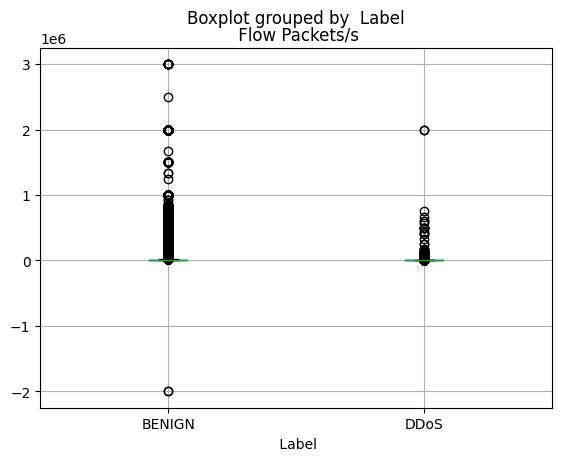

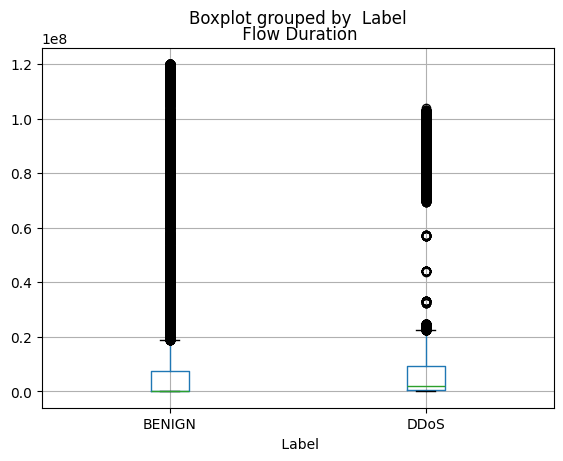

In [37]:

df_clean.boxplot(
    column=" Flow Packets/s",
    by=" Label"
)

plt.show()

df_clean.boxplot(
    column=" Flow Duration",
    by=" Label"
)

plt.show()

## Observation:
The Flow Packets/s feature exhibits a highly skewed distribution with numerous extreme outliers in both BENIGN and DDoS traffic. The presence of these outliers compresses the majority of observations near the lower end of the scale, indicating that data transformation or robust statistical measures may be required before modeling.


DDoS traffic generally exhibits higher flow durations than BENIGN traffic, as indicated by the higher median and broader interquartile range. This suggests that flow duration may contribute useful information for distinguishing between normal and attack traffic.

<Figure size 800x500 with 0 Axes>

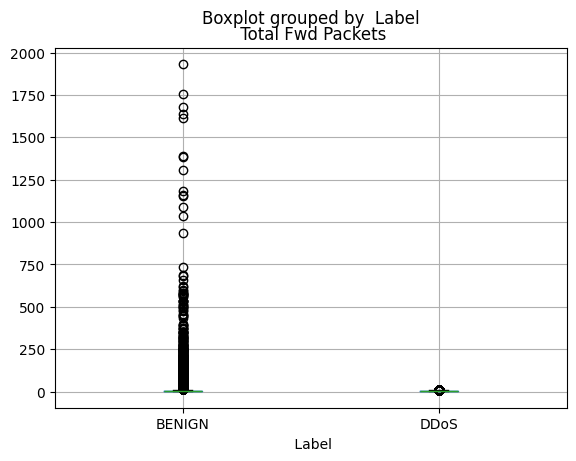

<Figure size 800x500 with 0 Axes>

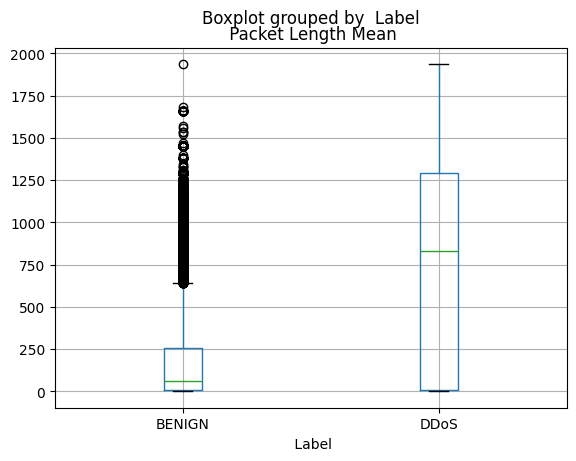

In [38]:
plt.figure(figsize=(8,5))

df_clean.boxplot(
    column=" Total Fwd Packets",
    by=" Label"
)

plt.show()
plt.figure(figsize=(8,5))

df_clean.boxplot(
    column=" Packet Length Mean",
    by=" Label"
)

plt.show()

## Observation:
 1. The Total Fwd Packets feature exhibits substantially greater variability in BENIGN traffic than in DDoS traffic. BENIGN flows contain numerous extreme outliers and higher packet counts, whereas DDoS flows appear concentrated around smaller packet counts. This suggests that DDoS traffic may consist of a large number of relatively short and repetitive flows.
 2. The Packet Length Mean feature shows a significant difference between BENIGN and DDoS traffic. DDoS flows exhibit substantially larger average packet lengths and a higher median value compared to BENIGN flows. The clear separation between the two distributions suggests that packet-length-related features may be highly informative for anomaly detection.

# End of Session Notes

## Findings

1. Dataset contains 225,745 flows and 79 features.
2. Labels are BENIGN and DDoS.
3. Only 30–34 infinite values were found in rate-based features.
4. Flow Packets/s exhibits heavy skewness and many outliers.
5. Packet Length Mean shows strong separation between BENIGN and DDoS traffic.
6. Total Fwd Packets shows lower variability for DDoS traffic.

## Next Steps

1. Data preprocessing.
2. Feature correlation analysis.
3. Feature selection.
4. Implement Z-Score anomaly detection.

### Research Notes:
1. Dataset contains 225,745 flows and 79 features.
2. Classes are relatively balanced (DDoS: 56.7%, BENIGN: 43.3%).
3. DDoS flows exhibit larger median flow durations than BENIGN flows.
4. A negative flow duration value (-1) exists in the dataset and requires preprocessing.
5. Certain records exhibit physically unrealistic values (e.g., negative packet rates), indicating the presence of data quality issues that must be addressed during preprocessing.